<a href="https://colab.research.google.com/github/Ashonet/CSCU9M6/blob/main/CSCU9M6_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Environment Setup

In [ ]:
import os, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau, ModelCheckpoint)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder

print(f"TensorFlow  : {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

TensorFlow  : 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### 1. Dataset Download

In [ ]:
#.csv file paths
TRAIN_CSV = os.path.join("sign_mnist_train.csv")
TEST_CSV  = os.path.join("sign_mnist_test.csv")

# Verify files exist
for path in [TRAIN_CSV, TEST_CSV]:
    if os.path.exists(path):
        print(f"Found: {path}  ({os.path.getsize(path)/1e6:.1f} MB)")
    else:
        print(f"MISSING: {path}")

Found: sign_mnist_train.csv  (83.3 MB)
Found: sign_mnist_test.csv  (21.8 MB)


### 1: Data Loading and Preprocessing

### 1.1 Load CSV and Convert to Image Tensors

In [ ]:
# Load raw CSVs
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

print(f"Train shape : {train_df.shape}   ({train_df['label'].nunique()} unique labels)")
print(f"Test  shape : {test_df.shape}")
print(f"\nClass distribution (train):")
print(train_df['label'].value_counts().sort_index().to_string())

Train shape : (27455, 785)   (24 unique labels)
Test  shape : (7172, 785)

Class distribution (train):
label
0     1126
1     1010
2     1144
3     1196
4      957
5     1204
6     1090
7     1013
8     1162
10    1114
11    1241
12    1055
13    1151
14    1196
15    1088
16    1279
17    1294
18    1199
19    1186
20    1161
21    1082
22    1225
23    1164
24    1118


In [ ]:
# Fit encoder on all observed labels so mapping is consistent
_le = LabelEncoder()
_le.fit(np.concatenate([train_df['label'].values, test_df['label'].values]))

def parse_df(df):
    labels  = _le.transform(df['label'].values)          # remap to 0-23
    pixels  = df.drop('label', axis=1).values
    images  = pixels.reshape(-1, 28, 28, 1).astype('float32')
    return images, labels

X_train_full, y_train_full = parse_df(train_df)
X_test,       y_test       = parse_df(test_df)

# Update the class-name lookup to use the encoder's ordering
NUM_CLASSES   = len(_le.classes_)                        # 24
CLASS_NAMES   = [chr(ord('A') + raw) for raw in _le.classes_]
LABEL_TO_LETTER = {i: CLASS_NAMES[i] for i in range(NUM_CLASSES)}

print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Pixel range: [{X_train_full.min()}, {X_train_full.max()}]")

Classes (24): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']
Pixel range: [0.0, 255.0]


### 1.2 Normalise Pixel Values to [0, 1]

In [ ]:
X_train_full = X_train_full / 255.0
X_test       = X_test       / 255.0

print(f"Pixel range after normalisation : [{X_train_full.min():.2f}, {X_train_full.max():.2f}]")

Pixel range after normalisation : [0.00, 1.00]


### 1.3 Validation Split (15% of training set)

In [ ]:
VAL_FRAC = 0.15

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=VAL_FRAC, random_state=SEED, stratify=y_train_full
)

print(f"Training   : {X_train.shape[0]:>6,} samples")
print(f"Validation : {X_val.shape[0]:>6,} samples")
print(f"Test       : {X_test.shape[0]:>6,} samples")

# Map label indices to letter names (J=9 and Z=25 are excluded in the dataset)
ALL_LETTERS = [chr(ord('A') + i) for i in range(26) if chr(ord('A') + i) not in ('J', 'Z')]
unique_labels = np.unique(y_train_full)
print(f"\nUnique labels in dataset: {unique_labels}")
NUM_CLASSES = len(unique_labels)
print(f"Number of classes: {NUM_CLASSES}")

# Build label-to-letter map from the actual unique labels
LABEL_TO_LETTER = {}
for lbl in unique_labels:
    letter = chr(ord('A') + lbl)
    LABEL_TO_LETTER[lbl] = letter
CLASS_NAMES = [LABEL_TO_LETTER[l] for l in unique_labels]
print(f"Class names: {CLASS_NAMES}")

Training   : 23,336 samples
Validation :  4,119 samples
Test       :  7,172 samples

Unique labels in dataset: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Number of classes: 24
Class names: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X']


### Exploratory Visualisation

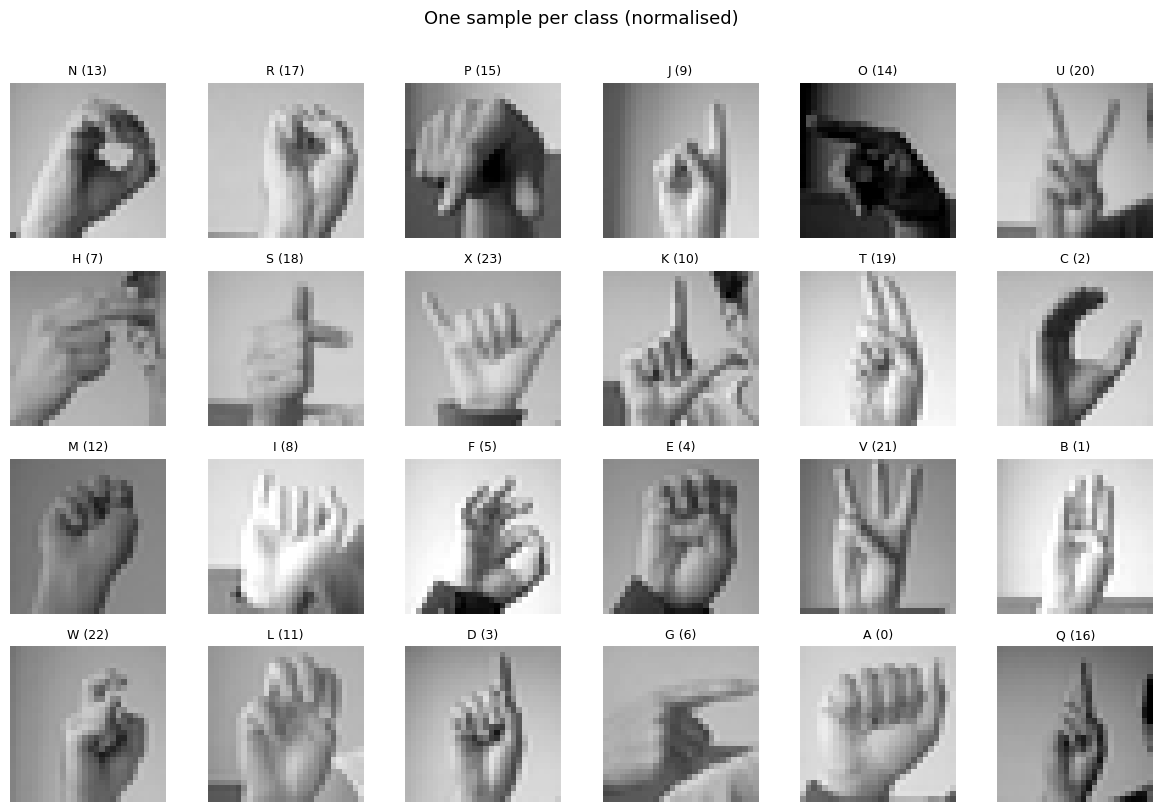

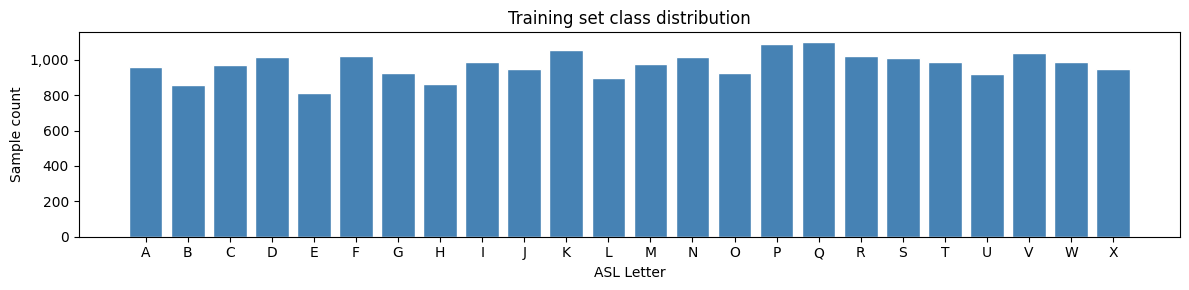

In [ ]:
fig, axes = plt.subplots(4, 6, figsize=(12, 8))
axes = axes.ravel()
shown = set()
idx = 0
for i, (img, lbl) in enumerate(zip(X_train, y_train)):
    if lbl not in shown and idx < 24:
        axes[idx].imshow(img.squeeze(), cmap='gray', vmin=0, vmax=1)
        axes[idx].set_title(f"{LABEL_TO_LETTER[lbl]} ({lbl})", fontsize=9)
        axes[idx].axis('off')
        shown.add(lbl)
        idx += 1
plt.suptitle("One sample per class (normalised)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("sample_per_class.png", dpi=120, bbox_inches='tight')
plt.show()

# Class distribution bar chart
fig, ax = plt.subplots(figsize=(12, 3))
counts = pd.Series(y_train).value_counts().sort_index()
ax.bar([LABEL_TO_LETTER[l] for l in counts.index], counts.values, color='steelblue', edgecolor='white')
ax.set_xlabel("ASL Letter")
ax.set_ylabel("Sample count")
ax.set_title("Training set class distribution")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=120)
plt.show()

### Data Augmentation Layer (used inside models)

In [ ]:
# The augmentation is embeded directly in the model graph so it is active only
# during training and frozen at inference, no data leakage risk.
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="augmentation")

---
## 2: CNN Architectures


### 2.1 Baseline CNN


In [ ]:
def build_baseline(input_shape=(28, 28, 1), num_classes=NUM_CLASSES, augment=True):
    inputs = keras.Input(shape=input_shape, name="input")
    x = inputs

    if augment:
        x = data_augmentation(x)

    # Block 1
    x = layers.Conv2D(32, 3, padding='same', use_bias=False, name="conv1a")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, 3, padding='same', use_bias=False, name="conv1b")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 2
    x = layers.Conv2D(64, 3, padding='same', use_bias=False, name="conv2a")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, 3, padding='same', use_bias=False, name="conv2b")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 3
    x = layers.Conv2D(128, 3, padding='same', use_bias=False, name="conv3")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling2D()(x)

    # Classifier head
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name="Baseline_CNN")

baseline = build_baseline()
baseline.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1a (Conv2D)                 │ (None, 28, 28, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1b (Conv2D)                 │ (None, 28, 28, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2a (Conv2D)                 │ (None, 14, 14, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2b (Conv2D)                 │ (None, 14, 14, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 7, 7, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │             

 Total params: 159,416 (622.72 KB)

 Trainable params: 158,776 (620.22 KB)

 Non-trainable params: 640 (2.50 KB)

### 2.2 Enhanced CNN — VGG-Style Architecture

In [ ]:
def vgg_block(x, filters, n_convs, name_prefix):
    shortcut = x
    for i in range(n_convs):
        x = layers.Conv2D(filters, 3, padding='same', use_bias=False,
                          name=f"{name_prefix}_conv{i+1}")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
    # 1x1 shortcut projection if channel dims differ
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding='same', use_bias=False,
                                 name=f"{name_prefix}_proj")(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.3)(x)
    return x


def build_vgg_style(input_shape=(28, 28, 1), num_classes=NUM_CLASSES, augment=True):
    inputs = keras.Input(shape=input_shape, name="input")
    x = inputs

    if augment:
        x = data_augmentation(x)

    # Stem
    x = layers.Conv2D(32, 3, padding='same', use_bias=False, name="stem")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # VGG-style blocks (28x28 -> 14 -> 7 -> 3 -> 1)
    x = vgg_block(x,  32, 2, "block1")   # -> 14x14
    x = vgg_block(x, 64, 2, "block2")   # -> 7x7
    x = vgg_block(x, 128, 3, "block3")   # -> 3x3

    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4),
                     name="fc1")(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4),
                     name="fc2")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name="predictions")(x)

    return keras.Model(inputs, outputs, name="VGG_Style_CNN")

vgg = build_vgg_style()
vgg.summary()

Model: "VGG_Style_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 28, 28, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 28, 28, 1) │          0 │ input[0][0]       │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem (Conv2D)       │ (None, 28, 28,    │        288 │ augmentation[1][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ stem[0][0]        │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 28, 28,    │      9,216 │ activation_5[0][… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 28, 28,    │      9,216 │ activation_6[0][… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 28, 28,    │          0 │ activation_7[0][… │
│                     │ 32)               │            │ activation_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 14, 14,    │          0 │ add[0][0]         │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 14, 14,    │          0 │ max_pooling2d_2[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 14, 14,    │     18,432 │ dropout_4[0][0]   │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        256 │ block2_conv1[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                 

 Total params: 525,112 (2.00 MB)

 Trainable params: 523,512 (2.00 MB)

 Non-trainable params: 1,600 (6.25 KB)

---
### 3: Training, Testing, and Evaluation

### 3.1 Hyperparameter Configuration & Training


In [ ]:
# Shared hyperparameters
BATCH_SIZE = 256
LR_INIT    = 1e-3
EPOCHS     = 30            # early stopping will terminate before this in practice

# Common callbacks
def make_callbacks(name):
    return [
        EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True,
                      verbose=1, mode='max'),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4,
                          min_lr=1e-6, verbose=1),
        ModelCheckpoint(f"{name}_best.keras", monitor='val_accuracy',
                        save_best_only=True, verbose=0)
    ]

# Compile helper
def compile_model(model, lr=LR_INIT):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

# Print parameter counts
def param_count(model):
    return sum(np.prod(v.shape) for v in model.trainable_variables)

print(f"Baseline  params : {param_count(baseline):>10,}")
print(f"VGG-style params : {param_count(vgg):>10,}")

Baseline  params :    158,776
VGG-style params :    523,512


In [ ]:
# Train Baseline CNN
compile_model(baseline)

t0 = time.time()
hist_baseline = baseline.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks("baseline"),
    verbose=1
)
baseline_time = time.time() - t0
print(f"\nBaseline training time: {baseline_time:.0f}s")

In [ ]:
# Train VGG-Style CNN
compile_model(vgg)

t0 = time.time()
hist_vgg = vgg.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks("vgg"),
    verbose=1
)
vgg_time = time.time() - t0
print(f"\nVGG-style training time: {vgg_time:.0f}s")